# **Inteligência Artificial Aplicada - 2026/1**

## **Trabalho 6: Redes Neurais Recorrentes**

**Professor:** Cícero Ferreira Fernandes Costa Filho  
**Aluno(a):** Maria Giovanna Gonçalves Sales - 22251138

Este trabalho consiste no treinamento e avaliação de uma rede LSTM para classificação de atividades a partir dos sinais x, y e z de acelerômetros.

# Importação das bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# Carregamento dos dados

O arquivo **dados.csv** contém 1724 linhas contendo informações dos acelerômetros.  
Cada linha contém 453 valores tipo “double” dos acelerômetros x, y e z relativos a uma atividade.  
Os primeiros 151 valores correspondem a dados do acelerômetro x, os 151 seguintes, a dados do acelerômetro y e os últimos 151 valores, a dados do acelerômetro z.  

O arquivo **labels.csv** contém também 1724 linhas com informações das atividades realizadas.  
Cada linha contém um número inteiro entre 1 e 9, correspondendo as atividades.

Existe uma correspondência entre uma linha do arquivo labels.csv e uma linha do arquivo dados.csv.

In [ ]:
# lê o arquivo de dados (1724 linhas × 453 colunas)
# header=None porque o arquivo não tem cabeçalho
X_raw = pd.read_csv('dados.csv', header=None).values
print(f"Shape dos dados carregados: {X_raw.shape}")

Shape dos dados carregados: (1724, 453)


In [ ]:
# lê o arquivo de labels (1724 linhas × 1 coluna)
y_raw = pd.read_csv('labels.csv', header=None).values.flatten()
print(f"Shape dos labels carregados: {y_raw.shape}")

Shape dos labels carregados: (1724,)


In [ ]:
# mostra quantas amostras existem por atividade
print("\nDistribuição das atividades:")
nomes_atividades = [
    'StandingUpFS',   # 1 - Levantando da cadeira
    'StandingUpFL',   # 2 - Levantando da cama
    'Walking',        # 3 - Caminhando
    'Running',        # 4 - Correndo
    'GoingUpS',       # 5 - Subindo escada
    'Jumping',        # 6 - Pulando
    'GoingDownS',     # 7 - Descendo escada
    'LyingDownFS',    # 8 - Deitando na cama
    'SittingDown'     # 9 - Sentando
]
for i, nome in enumerate(nomes_atividades, start=1):
    count = np.sum(y_raw == i)
    print(f"  Atividade {i} ({nome}): {count} amostras")


Distribuição das atividades:
  Atividade 1 (StandingUpFS): 42 amostras
  Atividade 2 (StandingUpFL): 46 amostras
  Atividade 3 (Walking): 373 amostras
  Atividade 4 (Running): 416 amostras
  Atividade 5 (GoingUpS): 258 amostras
  Atividade 6 (Jumping): 164 amostras
  Atividade 7 (GoingDownS): 308 amostras
  Atividade 8 (LyingDownFS): 62 amostras
  Atividade 9 (SittingDown): 55 amostras


# Pré-processamento dos dados
A LSTM espera dados no formato (amostras, passos_de_tempo, features).

Cada amostra tem 453 valores = 151 passos de tempo × 3 eixos (X, Y, Z).

Vamos reorganizar os dados nesse formato.

In [ ]:
NUM_AMOSTRAS = X_raw.shape[0] # 1724
PASSOS_TEMPO = 151 # 151 instantes de tempo por eixo
NUM_EIXOS = 3 # X, Y e Z

# separando os 3 eixos (cada um tem 151 valores por amostra)
X_x = X_raw[:, 0:151]           # x → colunas 0 a 150
X_y = X_raw[:, 151:302]         # y → colunas 151 a 301
X_z = X_raw[:, 302:453]         # z → colunas 302 a 452


In [ ]:
# empilhando os 3 eixos para formar (1724, 151, 3)
X = np.stack([X_x, X_y, X_z], axis=2)

print(f"Shape após reorganização (amostras, tempo, eixos): {X.shape}")
# Esperado: (1724, 151, 3)

Shape após reorganização (amostras, tempo, eixos): (1724, 151, 3)


# Normalização

Os dados terão média 0 e desvio padrão 1.

Fazemos isso por eixo (cada um dos 3 eixos separadamente).


In [ ]:
for i in range(NUM_EIXOS):
    scaler = StandardScaler()
    X[:, :, i] = scaler.fit_transform(X[:, :, i])

print("Normalização aplicada.")


Normalização aplicada.


Converte os labels de (1 a 9) para (0 a 8) - Python usa índice a partir de 0.

Convertemos para "one-hot encoding" também.


In [ ]:
y = y_raw - 1

NUM_CLASSES = 9
y_onehot = to_categorical(y, num_classes=NUM_CLASSES)
print(f"Shape dos labels (one-hot): {y_onehot.shape}")

Shape dos labels (one-hot): (1724, 9)


# Divisão em treino / validação

Dividimos os dados aleatoriamente:


*   85% para treinar a rede neural;  
*   15% para validar.


random_state=42 garante que sempre tenhamos a mesma divisão (reprodutível).  
stratify=y garante que todas as classes apareçam proporcionalmente nos dois conjuntos.

In [ ]:
X_treino, X_val, y_treino, y_val = train_test_split(
    X,          # dados de entrada
    y_onehot,   # labels (one-hot)
    test_size=0.15,      # 15% para validação
    random_state=42,     # semente para reprodutibilidade
    stratify=y           # mantém proporção das classes
)

print(f"Amostras de treino: {X_treino.shape[0]} ({X_treino.shape[0]/NUM_AMOSTRAS*100:.1f}%)")
print(f"Amostras de validação: {X_val.shape[0]} ({X_val.shape[0]/NUM_AMOSTRAS*100:.1f}%)")

Amostras de treino: 1465 (85.0%)
Amostras de validação: 259 (15.0%)


# Construção da rede LSTM

A LSTM (Long Short-Term Memory) é uma rede neural projetada para aprender padrões em sequências de dados, sendo ideal para séries temporais como os sinais de acelerômetro.

Arquitetura:

Entrada: (151 passos de tempo, 3 eixos)  

LSTM (128 unidades) → retorna sequências  
BatchNormalization   
Dropout (30%)    

LSTM (64 unidades)  → extrai padrões finais  
BatchNormalization    
Dropout (30%)                        

Dense (64 unidades, ReLU) → camada densa  
Dropout (20%)  

Dense (9 unidades, Softmax) → 9 classes  


In [ ]:
modelo = Sequential([

    # primeira camada lstm
    # 128 "células de memória" que aprendem padrões na sequência
    # return_sequences=True: passa a sequência inteira para a próxima camada lstm
    # input_shape: formato de entrada (151 instantes, 3 eixos)
    LSTM(128,
         return_sequences=True,
         input_shape=(PASSOS_TEMPO, NUM_EIXOS)),

    BatchNormalization(),

    # "desliga" aleatoriamente 30% dos neurônios para generalizar melhor
    Dropout(0.3),

    # segunda camada lstm
    # 64 unidades - camada menor. extrai padrões mais abstratos
    # return_sequences=False: agora retorna apenas o último passo de tempo
    LSTM(64,
         return_sequences=False),

    BatchNormalization(),
    Dropout(0.3),

    # camada densa
    # 64 neurônios com ativação relu: combina as features aprendidas pela lstm
    Dense(64, activation='relu'),
    Dropout(0.2),

    # camada de saída
    # 9 neurônios (um para cada atividade), com softmax
    # softmax converte as saídas em probabilidades que somam 1.0
    Dense(NUM_CLASSES, activation='softmax')
])


In [ ]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 151, 128)       │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 151, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 151, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,505 (478.54 KB)

 Trainable params: 122,121 (477.04 KB)

 Non-trainable params: 384 (1.50 KB)

# Compilação do modelo

- Otimizador: Adam (ajusta os pesos durante o treino)
- learning_rate=0.001: tamanho do "passo" ao ajustar os pesos
- Loss: categorical_crossentropy (função de erro para classificação multi-classe)
- Métricas: accuracy

In [ ]:
modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado.")

Modelo compilado.


# Callbacks

- EarlyStopping: para o treino automaticamente se a validação parar de melhorar
- patience=15: aguarda 15 épocas sem melhora antes de parar
- restore_best_weights=True: volta para os melhores pesos encontrados

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

- ReduceLROnPlateau: reduz o learning rate automaticamente quando estagna, "afinando" o aprendizado em etapas mais avançadas do treino.

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # multiplica o LR por 0.5
    patience=7,       # aguarda 7 épocas
    min_lr=1e-6,      # não deixa cair abaixo disso
    verbose=1
)

# Treinamento da rede

In [ ]:
historico = modelo.fit(
    X_treino, y_treino,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTreinamento concluído.")

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 353ms/step - accuracy: 0.1932 - loss: 2.3343 - val_accuracy: 0.2857 - val_loss: 2.0316 - learning_rate: 0.0010
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.3065 - loss: 1.8945 - val_accuracy: 0.3398 - val_loss: 1.9406 - learning_rate: 0.0010
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 318ms/step - accuracy: 0.3590 - loss: 1.7441 - val_accuracy: 0.3707 - val_loss: 1.7841 - learning_rate: 0.0010
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.4416 - loss: 1.5576 - val_accuracy: 0.4402 - val_loss: 1.6594 - learning_rate: 0.0010
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 333ms/step - accuracy: 0.5017 - loss: 1.4084 - val_accuracy: 0.5212 - val_loss: 1.3482 - learning_rate: 0.0010
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.5440 - loss: 1.2585 - val_accuracy: 0.6023 - val_loss: 1.1110 - learning_rate: 0.0010
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.5638 - l

# Avaliando no conjunto de validação

In [ ]:
loss_val, acc_val = modelo.evaluate(X_val, y_val, verbose=0)
print(f"\nAcurácia na validação: {acc_val * 100:.2f}%")
print(f"Loss na validação: {loss_val:.4f}")


Acurácia na validação: 93.82%
Loss na validação: 0.2134


In [ ]:
y_pred_prob = modelo.predict(X_val, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_real = np.argmax(y_val, axis=1)

print("\nRelatório de Classificação:")
print(classification_report(
    y_real, y_pred,
    target_names=nomes_atividades
))



Relatório de Classificação:
              precision    recall  f1-score   support

StandingUpFS       1.00      0.67      0.80         6
StandingUpFL       0.67      0.57      0.62         7
     Walking       1.00      0.98      0.99        56
     Running       1.00      1.00      1.00        63
    GoingUpS       1.00      0.90      0.95        39
     Jumping       0.96      0.96      0.96        25
  GoingDownS       0.87      1.00      0.93        46
 LyingDownFS       0.64      0.78      0.70         9
 SittingDown       0.71      0.62      0.67         8

    accuracy                           0.94       259
   macro avg       0.87      0.83      0.85       259
weighted avg       0.94      0.94      0.94       259



# Plotagem dos resultados

# Gráfico 1: Acurácia ao longo do treino

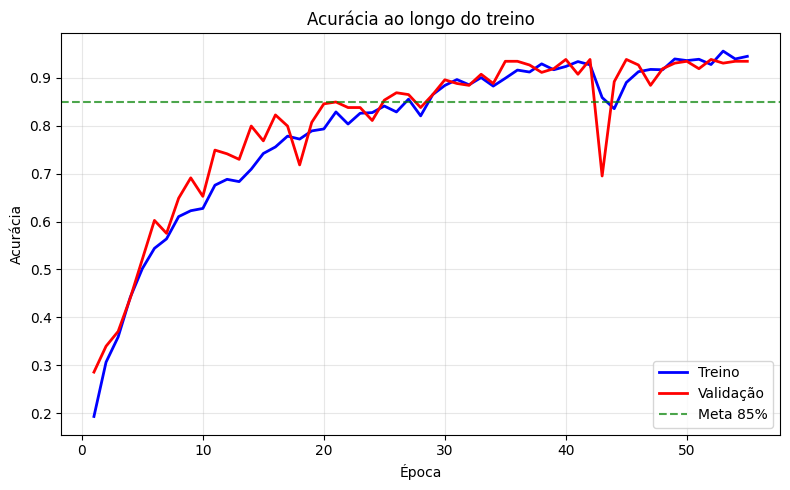

In [ ]:
epocas = range(1, len(historico.history['accuracy']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epocas, historico.history['accuracy'],     'b-', label='Treino',    linewidth=2)
plt.plot(epocas, historico.history['val_accuracy'], 'r-', label='Validação', linewidth=2)
plt.axhline(y=0.85, color='g', linestyle='--', alpha=0.7, label='Meta 85%')
plt.title('Acurácia ao longo do treino')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Perda ao longo do treino

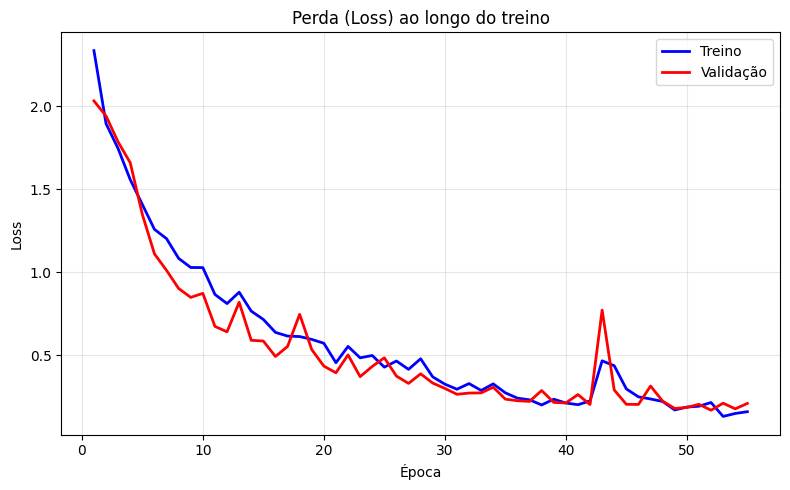

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epocas, historico.history['loss'],     'b-', label='Treino',    linewidth=2)
plt.plot(epocas, historico.history['val_loss'], 'r-', label='Validação', linewidth=2)
plt.title('Perda (Loss) ao longo do treino')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 3: Matriz de confusão

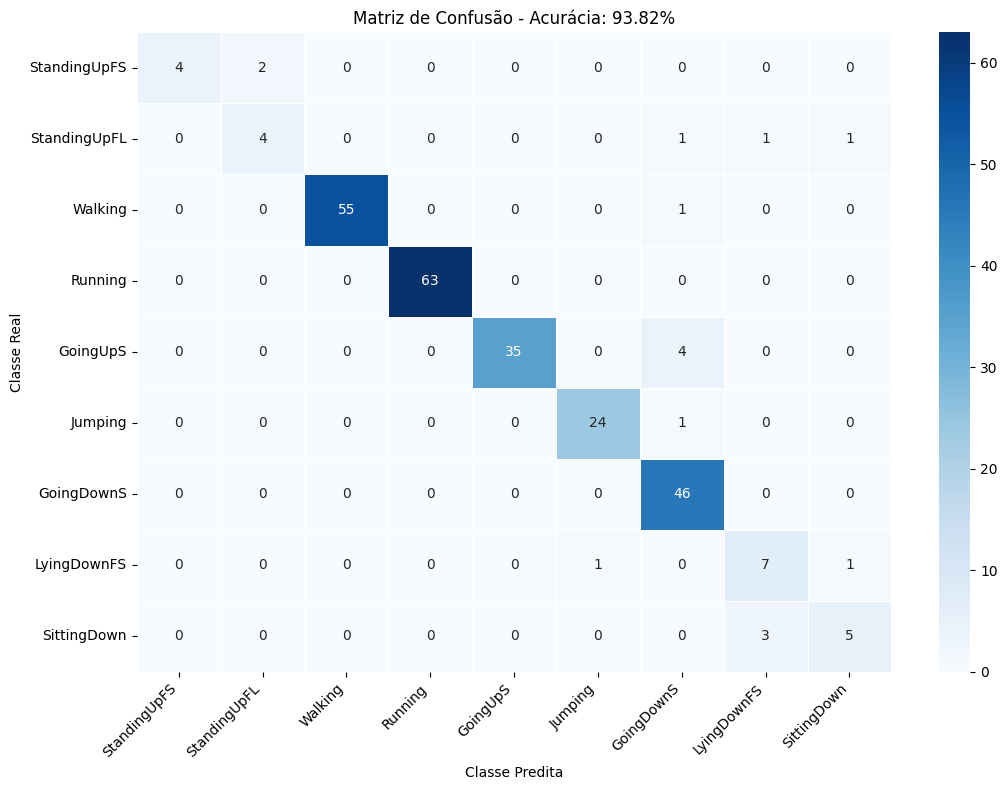

In [ ]:
cm = confusion_matrix(y_real, y_pred)
plt.figure(figsize=(11, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nomes_atividades,
    yticklabels=nomes_atividades,
    linewidths=0.5
)
plt.title(f'Matriz de Confusão - Acurácia: {acc_val*100:.2f}%')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()